# Machine Learning: Regresión

## Ejercicio 1

Dado un conjunto de descriptores de una canción, el objetivo es predecir el año de producción de la canción. Básicamente se trata de un problema de regresión, ya que se debe predecir un número en el rango de 1922 y 2011.

Source:https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

** Descripción del dataset**

90 atributos:

- 12 = timbre average
- 78 = timbre covariance


**Instrucciones**:

1. Importe los datos de data/millionsong.txt

In [ ]:
# Respuesta

import numpy as np
import pandas as pd

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import time

dataset = pd.read_csv('data/millionsong.txt', header=None)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2001.0,0.884124,0.610454,0.600498,0.474669,0.247233,0.357306,0.344136,0.339641,0.600859,0.425705,0.604915,0.419193
1,2001.0,0.854412,0.604125,0.593634,0.495885,0.266308,0.261472,0.506387,0.464454,0.665799,0.542969,0.580444,0.445219
2,2001.0,0.908983,0.632063,0.557429,0.498264,0.276396,0.312810,0.448530,0.448674,0.649791,0.489869,0.591908,0.450002
3,2001.0,0.842525,0.561827,0.508715,0.443531,0.296734,0.250214,0.488541,0.360509,0.575435,0.361006,0.678379,0.409037
4,2001.0,0.909303,0.653608,0.585581,0.473251,0.251417,0.326977,0.404323,0.371155,0.629402,0.482243,0.566901,0.463374


In [ ]:
# Respuesta

# Obtenemos el target, que es la primera columna del dataset
y = dataset.loc[:, 0].apply(lambda x: int(x))

# Obtenemos el dataset con el resto de atributos
x = dataset.drop(0, axis=1)

# Aquí dividimos el dataset en train y test, para entrenar y validar nuestro modelo respectivamente.
(x_train, x_test, y_train, y_test) = train_test_split(x, y, test_size=0.3)

# Vemos que las distribuciones de las predicciones se han centrado en 1980.

Visualice y train y y test

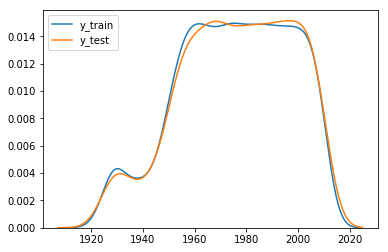

In [ ]:
# Respuesta

sns.kdeplot(y_train, label='y_train')
sns.kdeplot(y_test, label='y_test')

Ajuste un modelo de regresión para predecir el año de una canción.

In [ ]:
# Respuesta

pred = LinearRegression()
pred.fit(x_train, y_train)

y_pred = pred.predict(x_test)

Muestre las métricas y gráficas que considere necesarias para poder argumentar si el modelo está funcionando bien.

In [ ]:
# Respuesta

mean_absolute_error(y_test, y_pred)

pred.coef_

y_pred

array([1964.60133808, 1982.55730825, 1979.56933758, ..., 1935.48175147,
       1994.99693324, 1986.88624223])

Visualize los resultados de las predicciones

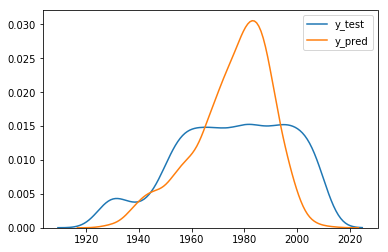

In [ ]:
# Respuesta

sns.kdeplot(y_test, label='y_test')
sns.kdeplot(y_pred, label='y_pred')
# Vemos que las distribuciones de las predicciones se han centrado en 1980.

Vamos a unir los valores de test y las predicciones en un DataFrame para poder hacer gráficos

In [ ]:
# Respuesta

# Notad que y_test era un pandas.Series y que hemos obtenido sus values. Esto era para asociar sus
ys = pd.concat([pd.Series(y_test.values, name='y_test'), pd.Series(y_pred, name='y_pred')], axis=1)

Para comenzar vamos a mostrar una comparación entre las predicciones y los valores reales

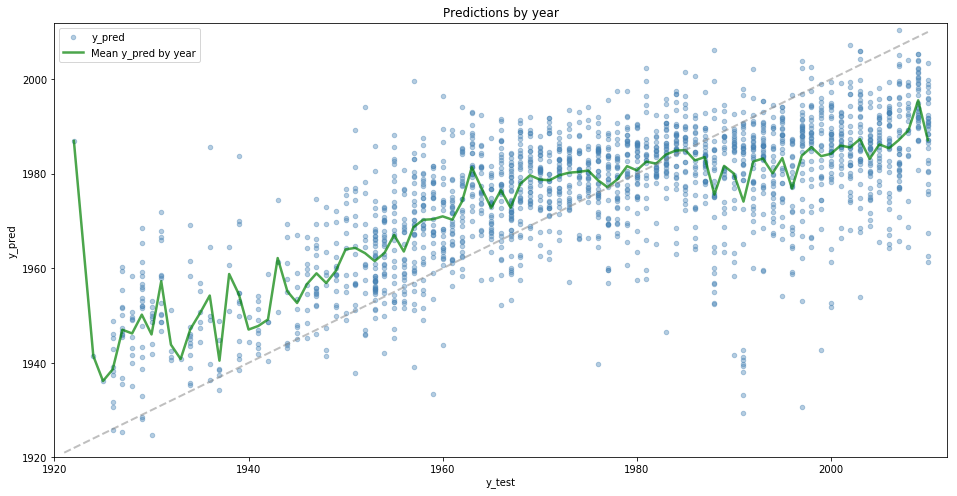

In [ ]:
# Respuesta

ax = ys.sort_values('y_test').plot(x='y_test', y='y_pred', kind='scatter', alpha=0.4, c='steelblue',
                                   xlim=(1920, 2012), ylim=(1920, 2012), figsize=(16,8),
                                   label='y_pred', title='Predictions by year')
ys.groupby('y_test').mean().plot(y='y_pred', c='green', lw=2.5, alpha=0.7, label='Mean y_pred by year', ax=ax)
plt.plot([1921, 2010], [1921, 2010], linewidth=2, alpha=0.5, c='gray', ls='--', label='Perfect Fit')
plt.show()

Vamos a mostrar un plot con los residuos

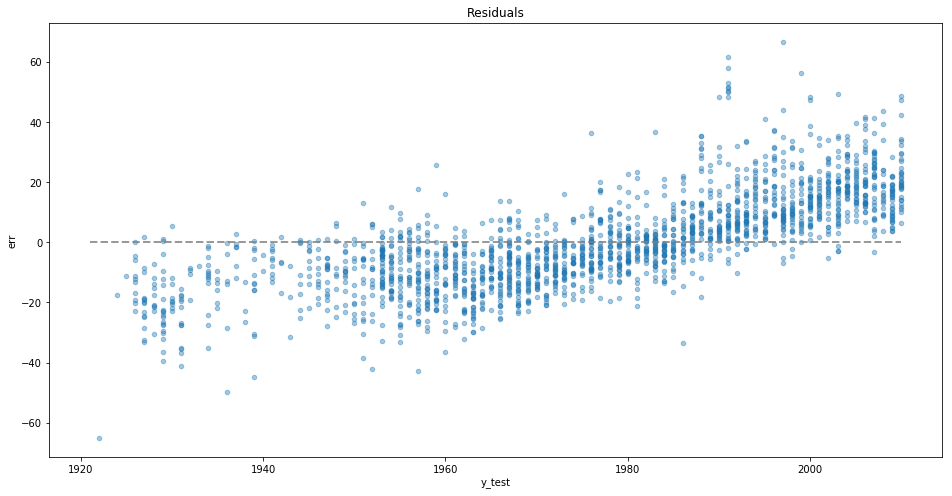

In [ ]:
# Respuesta

ys['err'] = ys['y_test'] - ys['y_pred']
ys.sort_values('y_test').plot(kind='scatter', x='y_test', y='err', figsize=(16,8), alpha=0.4, title='Residuals')
plt.plot([1921, 2010], [0, 0], linewidth=2, alpha=0.8, ls='--', c='gray')
plt.show()

Y ahora vamos a mostrar el Error absoluto en años para cada año del conjunto de test.

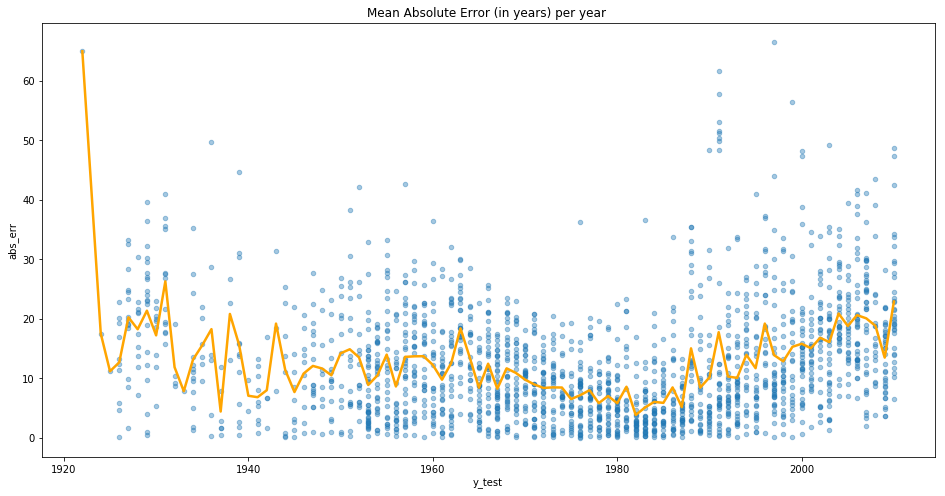

In [ ]:
# Respuesta

ys['abs_err'] = np.abs(ys['y_test'] - ys['y_pred'])     # Error absoluto
ys.sort_values('y_test').plot(kind='scatter', x='y_test', y='abs_err', figsize=(16,8), alpha=0.4)
ys.groupby('y_test').mean()['abs_err'].plot(c='orange', lw=2.5, title='Mean Absolute Error (in years) per year ')
plt.show()

---

## Ejercicio 2

EL dataset de diabetes consiste en 10 variables fisológicas (edad, sexo, peso, presión arterial, y seis pruebas sanguíneas) de 442 pacientes, y la indicación del progreso de la enfermedad después de un año.

Ajuste y compare los modelos de regresión obtenidos al considerar el primer atributo (edad) y todos los atributos del dataset.

*Source*: http://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf

In [ ]:
from sklearn import datasets
diabetes = datasets.load_diabetes()

X, y = diabetes.data, diabetes.target

((442, 10), (442,))

In [ ]:
diabetes_cols = ['Age', 'Sex', 'Body mass index', 'Average blood pressure',
                 'S1', 'S2', 'S3', 'S4', 'S5', 'S6']      # S1-S6 are 6 blood-serum measurements on each patient

Explore el dataset

In [ ]:
# Respuesta

X.shape, y.shape
diabetes_df['y'] = pd.Series(y)
diabetes_df = pd.DataFrame(X, columns=diabetes_cols)
diabetes_df.head()

,Age,Sex,Body mass index,Average blood pressure,S1,S2,S3,S4,S5,S6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641


Visualize la relación entre las variables

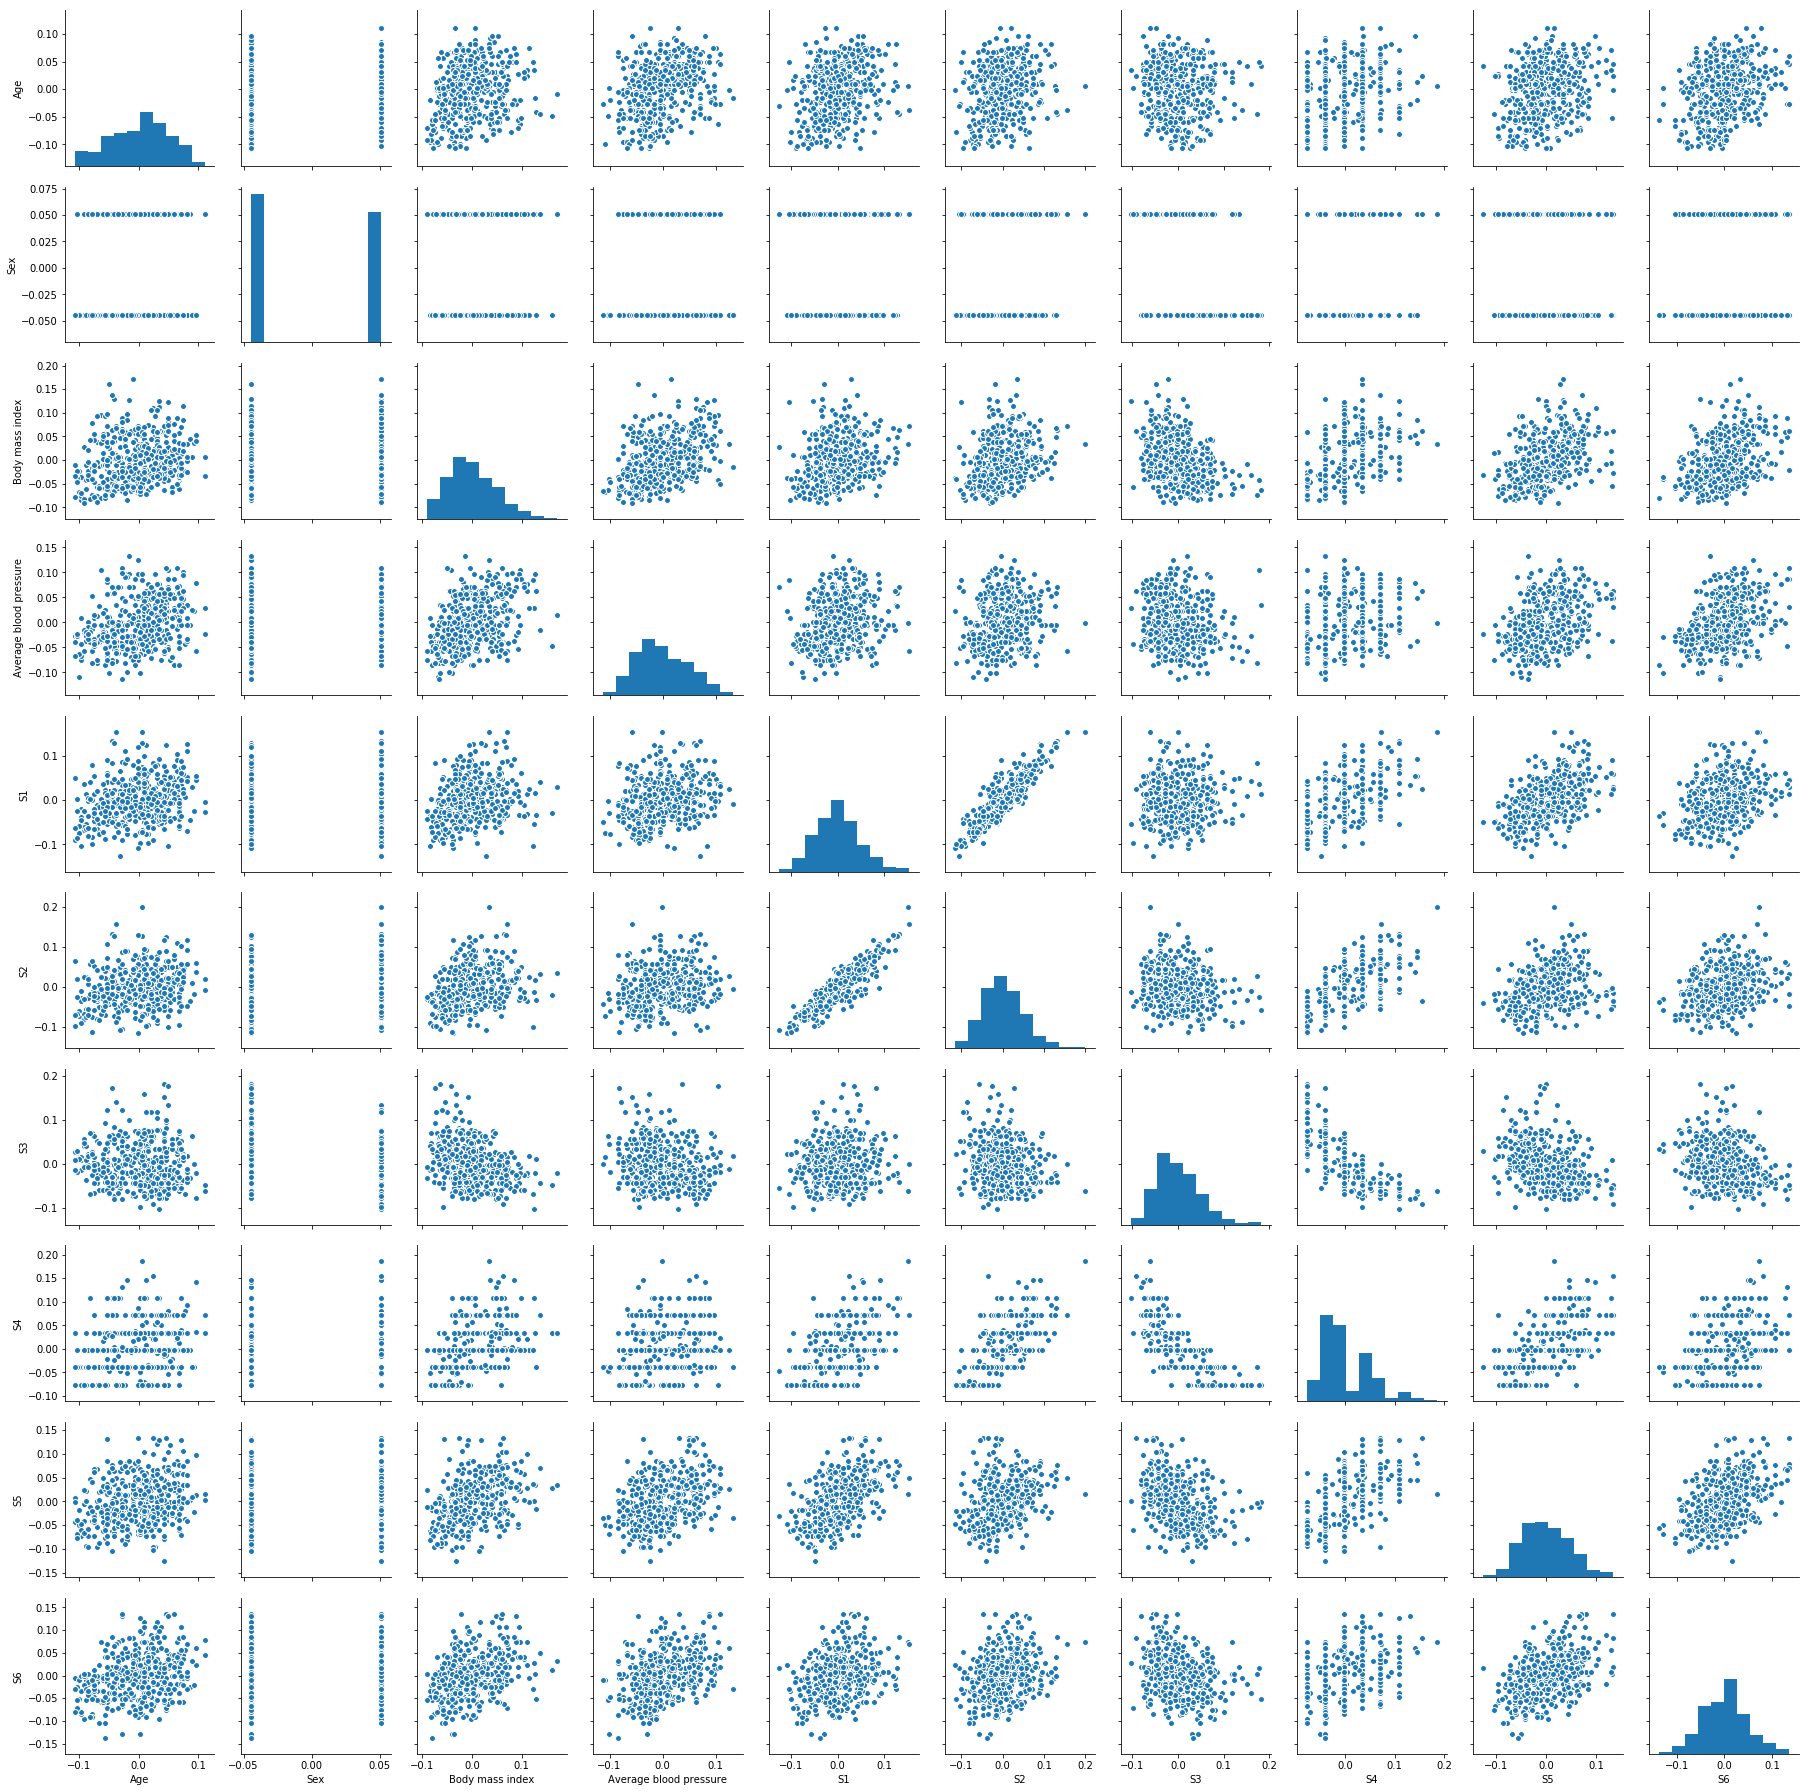

In [ ]:
# Respuesta

sns.pairplot(diabetes_df)

Construya un modelo de regresion

In [ ]:
# Respuesta

X1 = X[:, np.newaxis, 2]    # X1 gets only one variable: `age`
X2 = X                      # X2 gets all predictor variables

X.shape, y.shape

X1.shape, X2.shape

x1_train, x1_test, x2_train, x2_test, y_train, y_test = train_test_split(X1, X2, y)

x1_train.shape, x1_test.shape, x2_train.shape, x2_test.shape, y_train.shape, y_test.shape

regressor1 = LinearRegression()
regressor2 = LinearRegression()

regressor1.fit(x1_train, y_train)    # Train with variable: age
regressor2.fit(x2_train, y_train)    # Train with all variables

y1_pred = regressor1.predict(x1_test)
y2_pred = regressor2.predict(x2_test)

print('Los coeficientes del primer modelo son:\n', regressor1.coef_)
print('Los coeficientes del segundo modelo son:\n', regressor2.coef_)

print('El error del primer modelo es:\n', mean_absolute_error(y_test, y1_pred))
print('El error del segundo modelo es:\n', mean_absolute_error(y_test, y2_pred))

Los coeficientes del primer modelo son:
 [945.20167461]
Los coeficientes del segundo modelo son:
 [ -43.06942979 -258.47536666  500.62088212  365.60829609 -930.54965865
  473.32952727  215.8502678   305.41295615  779.68562751  112.18462919]
El error del primer modelo es:
 48.980338447162715
El error del segundo modelo es:
 43.001924605440074


Analiza los residuos de la regresion. Visualizelos así como las desviaciones de la predicción

/home/srodriguezsp/.conda/envs/ds_fundamentals/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


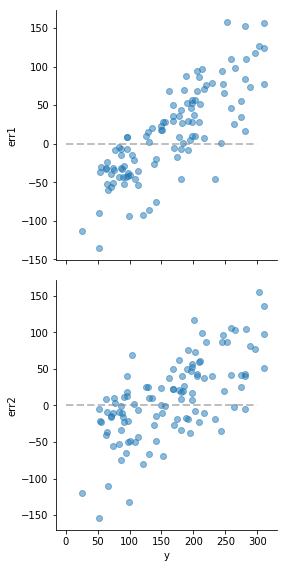

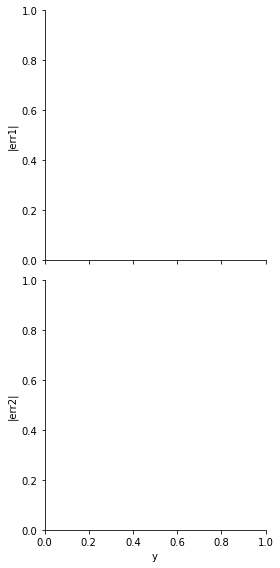

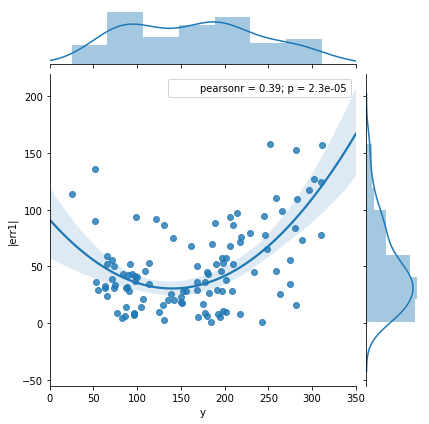

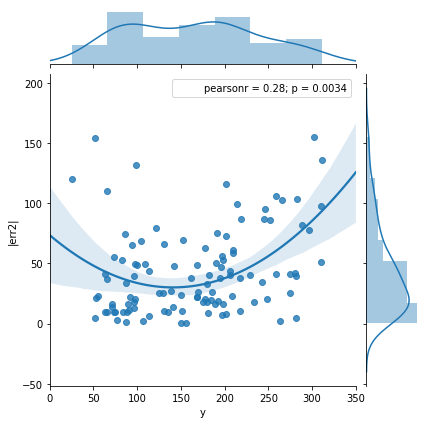

In [ ]:
# Respuesta

# Vamos a mostrar unas gráficas para entender donde falla la regresión
# Primero pasamos las *y* a DataFrame para poder generar gráficas de manera sencilla
ys = pd.DataFrame({'y': y_test, 'ŷ1': y1_pred, 'ŷ2': y2_pred,
                    'err1': y_test - y1_pred, '|err1|': np.abs(y_test - y1_pred),
                    'err2': y_test - y2_pred, '|err2|': np.abs(y_test - y2_pred)})
ys = ys[['y', 'ŷ1', 'ŷ2', 'err1', 'err2', '|err1|', '|err2|']]   # rearanging columns
ys.head()

g = sns.PairGrid(ys, size=4,
                 x_vars=['y'], y_vars=["err1", "err2"])
g = g.map(plt.scatter, alpha=.5)
for ax in g.axes.ravel():
    ax.plot((0, 300), (0, 0), linewidth=2, alpha=0.5, ls='--', c='gray')

g = sns.PairGrid(ys, size=4, x_vars=['y'], y_vars=["|err1|", "|err2|"])
g = g.map(sns.jointplot, kind='reg', order=2, xlim=(0,350))

# Vemos que los errores son mayores en valores bajos y altos de y. Una solución a este problema sería aplicar un modelo no lineal.